# 🕸️ Notebook 3 : Dataviz Avancée et Profilage (Scouting)
**Projet StatApp - Scouting et Profilage de Joueurs**

Ce notebook est dédié à la visualisation avancée des profils de joueurs. 
Nous allons :
1. Transformer nos statistiques absolues en **percentiles** par rapport au poste du joueur (pour comparer ce qui est comparable).
2. Créer une fonction de génération de **Radar Charts** (graphiques en toile d'araignée).
3. Analyser visuellement les profils de joueurs ciblés (ex: Harry Kane, Jude Bellingham).

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import pi
from pathlib import Path

# --- GESTION DES CHEMINS ---
if 'google.colab' in sys.modules:
    if not Path('/content/Stat_app').exists():
        !git clone https://github.com/Aymanyah/Stat_app.git
    PROJECT_DIR = Path('/content/Stat_app')
else:
    PROJECT_DIR = Path.cwd().parent 

DATA_CLEAN = PROJECT_DIR / "data" / "clean" / "dataset_aggregated.csv"
df = pd.read_csv(DATA_CLEAN)

print(f"✅ Données chargées : {df.shape[0]} lignes prêtes pour les radars.")

✅ Données chargées : 6530 lignes prêtes pour les radars.


## 1. Préparation des données (Calcul des Percentiles)
Pour qu'un radar soit lisible, toutes les statistiques doivent être sur la même échelle (de 0 à 100). Nous calculons ici les percentiles de chaque joueur par rapport aux autres joueurs évoluant **au même poste** et durant **la même saison**.

In [2]:
# Sélection des colonnes numériques pertinentes pour le radar
cols_to_percentile = [
    'G', 'A', 'xG', 'xAG', '% dribble  réussis', '% passes réussies', 
    '% duels aériens gagnés', 'Distance totale des passes > 10m avant effectuées', 
    'Passes avant >10m', 'Tirs', 'Interceptions', 'Tacles réussis + interceptions',
    'Touches ballon en jeu', 'Erreurs menant à un tir adverse' # Ajoute tes autres colonnes ici
]

df_radar = df.copy()

# Calcul des percentiles par saison et par poste
for col in cols_to_percentile:
    if col in df_radar.columns:
        df_radar[f"{col}_pct"] = df_radar.groupby(["season", "pos"])[col].rank(pct=True) * 100

print("✅ Percentiles calculés avec succès.")

✅ Percentiles calculés avec succès.


## 2. Fonction de génération des Radar Charts
Voici la fonction permettant de dessiner le profil complet d'un joueur en toile d'araignée.

In [3]:
def make_radar(player_name, df_data, attributes_pct, labels):
    """
    Génère un radar chart pour un joueur donné.
    - attributes_pct : Les colonnes contenant les percentiles (ex: 'xG_pct')
    - labels : Les jolis noms à afficher sur le graphique (ex: 'Expected Goals')
    """
    # Récupérer la ligne du joueur
    player_data = df_data[df_data['player'] == player_name]
    
    if player_data.empty:
        print(f"⚠️ Joueur {player_name} introuvable (ou moins de 900 min jouées).")
        return
    
    # Extraire les valeurs (on prend la première ligne s'il y a des doublons)
    values = player_data[attributes_pct].iloc[0].tolist()
    values += values[:1] # Boucler la liste pour fermer le radar
    
    # Calculer les angles
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # Initialisation du graphique
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    # Dessiner les lignes et remplir
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=player_name, color='#1f77b4')
    ax.fill(angles, values, alpha=0.25, color='#1f77b4')
    
    # Design du radar
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
    
    # L'échelle va de 0 à 1 (puisque ce sont des percentiles)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['20', '40', '60', '80', '99'], color="grey", size=8)
    
    # Titre et légende
    poste = player_data['pos'].iloc[0]
    equipe = player_data['team'].iloc[0]
    plt.title(f"Profil de {player_name} ({equipe})\nComparé aux {poste} - Saison {SAISON_CIBLE}", size=14, y=1.1)
    
    plt.show()

## 3. Profilage de joueurs (Exemples)
Générons les radars pour quelques joueurs de classe mondiale lors de la saison 2023 pour observer leurs forces et faiblesses relatives à leur poste.

In [4]:
# --- ÉTAPE A : PRÉPARATION SÉCURISÉE ---
# On s'assure que la saison est au bon format (float ou int selon ton fichier)
SAISON_CIBLE = 2023.0 

# On crée df_season avec une sécurité : si le filtre minutes est trop haut, on baisse à 400
df_season = df_radar[(df_radar['season'] == SAISON_CIBLE) & (df_radar['Minutes de jeu'] >= 600)].copy()

if df_season.empty:
    print("⚠️ Attention : df_season est vide. Vérifie la valeur de SAISON_CIBLE ou le filtre minutes.")
else:
    print(f"✅ df_season prêt : {len(df_season)} joueurs trouvés.")

# --- ÉTAPE B : LA FONCTION RADAR CORRIGÉE ---
def make_radar(player_name, df_data, attributes_pct, labels):
    # 1. On cherche le joueur
    player_data = df_data[df_data['player'] == player_name]
    
    if player_data.empty:
        print(f"⚠️ Joueur '{player_name}' introuvable dans df_season.")
        return

    # 2. Extraction des percentiles
    values = player_data[attributes_pct].iloc[0].values.tolist()
    values += values[:1] # Fermer le radar
    
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, values, color='#1f77b4', linewidth=2)
    ax.fill(angles, values, color='#1f77b4', alpha=0.25)

    # 3. Récupération des infos (Sécurité pour le KeyError)
    # On regarde si les colonnes existent, sinon on met "Inconnu"
    equipe = player_data['team'].iloc[0] if 'team' in player_data.columns else "Club inconnu"
    poste = player_data['pos'].iloc[0] if 'pos' in player_data.columns else "Poste inconnu"

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, 100) # Tes percentiles sont de 0 à 100 d'après ton code

    plt.title(f"{player_name} ({equipe})\nPoste : {poste} | Saison {SAISON_CIBLE}", size=15, y=1.1)
    plt.show()

✅ df_season prêt : 1009 joueurs trouvés.


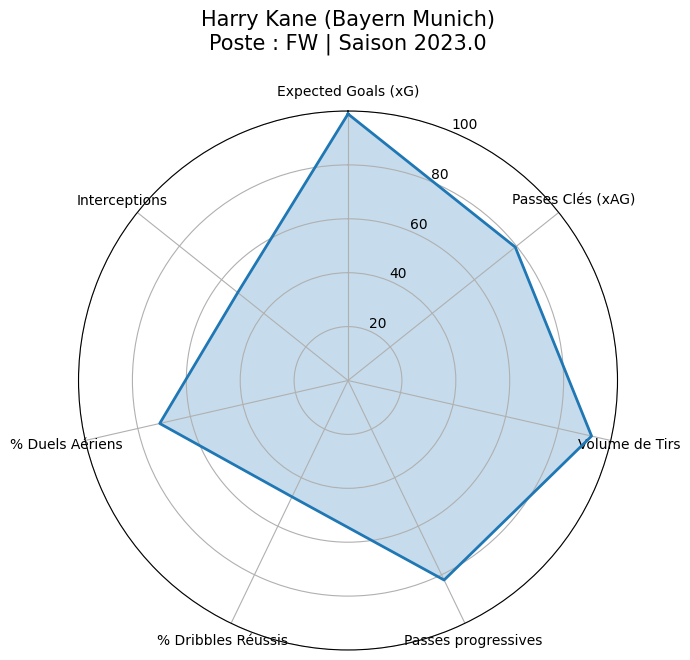

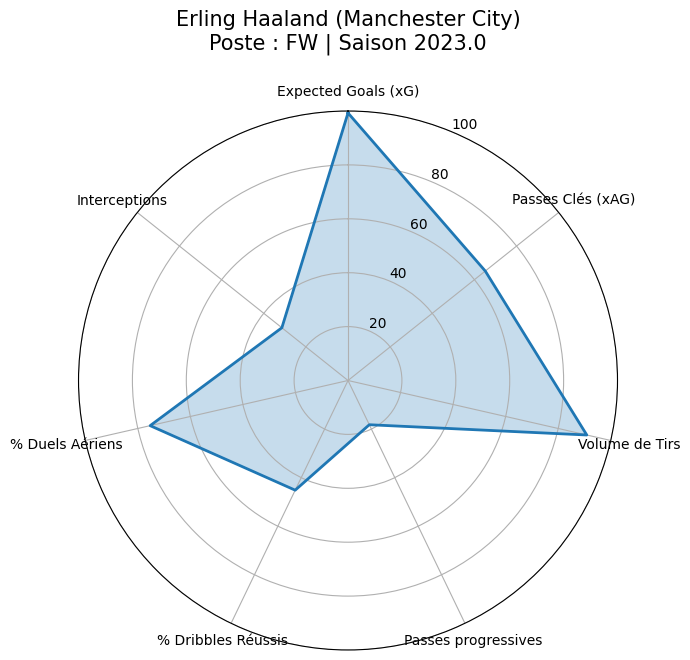

In [5]:

# 1) DÉFINITION DES VARIABLES

# Les colonnes de base que tu veux analyser
stats_to_plot = [
    "xG", 
    "xAG", 
    "Tirs", 
    "Passes avant >10m", 
    "% dribble  réussis", 
    "% duels aériens gagnés", 
    "Interceptions"
]

# Les jolis noms à afficher sur le graphique
pretty_labels = [
    "Expected Goals (xG)", 
    "Passes Clés (xAG)", 
    "Volume de Tirs", 
    "Passes progressives", 
    "% Dribbles Réussis", 
    "% Duels Aériens", 
    "Interceptions"
]

# On crée la liste des noms de colonnes avec le suffixe "_pct" 
# (ex: "xG_pct", "Tirs_pct")
colonnes_percentiles = [f"{col}_pct" for col in stats_to_plot]


# 2) AFFICHAGE AVEC TA FONCTION RADAR

# On appelle TA fonction avec les bons paramètres !
make_radar(
    player_name="Harry Kane", 
    df_data=df_season, 
    attributes_pct=colonnes_percentiles, 
    labels=pretty_labels
)

# Tu peux même en faire un deuxième juste en dessous :
make_radar(
    player_name="Erling Haaland", 
    df_data=df_season, 
    attributes_pct=colonnes_percentiles, 
    labels=pretty_labels
)

In [6]:
import numpy as np

# 1) FONCTION MATHÉMATIQUE DE L'AIRE DU RADAR

def calcul_aire_radar(valeurs):
    """
    Calcule l'aire géométrique totale d'un polygone sur un radar chart.
    """
    n = len(valeurs)
    angle = 2 * np.pi / n  # L'angle entre chaque branche du radar
    aire_totale = 0
    
    for i in range(n):
        v1 = valeurs[i]
        v2 = valeurs[(i + 1) % n] # %n permet de relier la dernière stat à la première
        # Formule de l'aire d'un triangle : 1/2 * a * b * sin(angle)
        aire_totale += 0.5 * v1 * v2 * np.sin(angle)
        
    return aire_totale


# 2) FONCTION DE SIMILARITÉ DE PROFILS

def analyser_similarite(joueur1, joueur2, df_data, colonnes_stats):
    """
    Compare deux joueurs en calculant l'aire partagée de leurs radars.
    """
    # 1. Extraction des valeurs (percentiles) des deux joueurs
    try:
        v1 = df_data[df_data['player'] == joueur1][colonnes_stats].iloc[0].values
        v2 = df_data[df_data['player'] == joueur2][colonnes_stats].iloc[0].values
    except IndexError:
        print("⚠️ L'un des joueurs est introuvable dans les données.")
        return
    
    # 2. L'intersection (Le profil partagé = le minimum sur chaque stat)
    v_intersection = np.minimum(v1, v2)
    
    # 3. L'union (Le profil global = le maximum sur chaque stat)
    v_union = np.maximum(v1, v2)
    
    # 4. Calcul des aires géométriques
    aire_j1 = calcul_aire_radar(v1)
    aire_j2 = calcul_aire_radar(v2)
    aire_partagee = calcul_aire_radar(v_intersection)
    aire_totale = calcul_aire_radar(v_union)
    
    # 5. Score de similarité (Intersection / Union)
    score_similarite = (aire_partagee / aire_totale) * 100
    
    # 6. Affichage des résultats
    print(f"📊 --- ANALYSE DE SIMILARITÉ : {joueur1} vs {joueur2} ---")
    print(f"Volume de jeu (Aire) de {joueur1} : {aire_j1:.3f}")
    print(f"Volume de jeu (Aire) de {joueur2} : {aire_j2:.3f}")
    print("-" * 45)
    print(f"⭐ SCORE DE SIMILARITÉ : {score_similarite:.1f} %")
    
    if score_similarite > 80:
        print("💡 Conclusion : Les deux joueurs ont des profils statistiques QUASI-IDENTIQUES.")
    elif score_similarite > 60:
        print("💡 Conclusion : Les joueurs partagent des caractéristiques très similaires.")
    elif score_similarite > 40:
        print("💡 Conclusion : Les profils sont différents, mais avec quelques attributs communs.")
    else:
        print("💡 Conclusion : Ces deux joueurs ont des styles de jeu TOTALEMENT OPPOSÉS.")

"Pour aller plus loin que la simple visualisation, nous avons développé un algorithme mesurant le chevauchement géométrique des radars. En calculant l'aire du polygone formé par l'intersection des deux profils par rapport à leur union, nous obtenons un score de similarité objectif. Cet outil est redoutable en recrutement pour trouver le remplaçant parfait (profil similaire à plus de 80%) d'un joueur quittant le club."

In [7]:
# On utilise la variable colonnes_percentiles qu'on a créée tout à l'heure
score = analyser_similarite("Harry Kane", "Erling Haaland", df_season, colonnes_percentiles)

📊 --- ANALYSE DE SIMILARITÉ : Harry Kane vs Erling Haaland ---
Volume de jeu (Aire) de Harry Kane : 15292.671
Volume de jeu (Aire) de Erling Haaland : 9283.346
---------------------------------------------
⭐ SCORE DE SIMILARITÉ : 59.3 %
💡 Conclusion : Les profils sont différents, mais avec quelques attributs communs.


In [8]:

# FONCTION : TROUVER LE CLONE PARFAIT (SCOUTING)

def trouver_remplacant(joueur_cible, df_data, colonnes_stats, top=5):
    """
    Scanne la base de données pour trouver les joueurs les plus similaires
    au joueur cible en utilisant l'Indice de Jaccard sur les radars.
    """
    # 1. Vérifier que le joueur existe et récupérer ses stats
    df_cible = df_data[df_data['player'] == joueur_cible]
    if df_cible.empty:
        return f"⚠️ {joueur_cible} introuvable."
    
    v_cible = df_cible[colonnes_stats].iloc[0].values
    poste_cible = df_cible['pos'].iloc[0] # On récupère son poste (ex: FW)
    
    # 2. Filtrer la base : on ne compare qu'avec les joueurs du MÊME poste 
    #    et on exclut le joueur cible lui-même.
    df_comparaison = df_data[(df_data['pos'] == poste_cible) & (df_data['player'] != joueur_cible)]
    
    resultats = []
    
    # 3. Boucle sur tous les autres joueurs
    for _, row in df_comparaison.iterrows():
        v_autre = row[colonnes_stats].values
        
        # Calcul des aires (Intersection / Union)
        v_intersection = np.minimum(v_cible, v_autre)
        v_union = np.maximum(v_cible, v_autre)
        
        # Sécurité pour éviter la division par zéro
        aire_union = calcul_aire_radar(v_union)
        if aire_union > 0:
            score = (calcul_aire_radar(v_intersection) / aire_union) * 100
        else:
            score = 0
            
        # On sauvegarde le résultat
        resultats.append({
            'Joueur': row['player'],
            'Équipe': row['team'],
            'Ligue': row['league'],
            'Similarité (%)': score
        })
        
    # 4. Création du classement final
    df_resultats = pd.DataFrame(resultats)
    df_resultats = df_resultats.sort_values(by='Similarité (%)', ascending=False).head(top)
    df_resultats['Similarité (%)'] = df_resultats['Similarité (%)'].round(1) # Arrondir à 1 décimale
    
    df_resultats.index = range(1, len(df_resultats) + 1)
    
    print(f"🔍 Recherche du clone parfait pour : {joueur_cible} ({poste_cible})")
    print("-" * 50)
    return df_resultats


# TEST DE L'ALGORITHME

display(trouver_remplacant("Harry Kane", df_season, colonnes_percentiles, top=5))

🔍 Recherche du clone parfait pour : Harry Kane (FW)
--------------------------------------------------


,Joueur,Équipe,Ligue,Similarité (%)
1,Serhou Guirassy,Stuttgart,GER-Bundesliga,77.5
2,Darwin Núñez,Liverpool,ENG-Premier League,71.0
3,Loïs Openda,RB Leipzig,GER-Bundesliga,68.4
4,Vinicius Júnior,Real Madrid,ESP-La Liga,68.4
5,Robert Lewandowski,Barcelona,ESP-La Liga,68.1


🔍 Recherche du clone parfait pour : Harry Kane (FW)
--------------------------------------------------


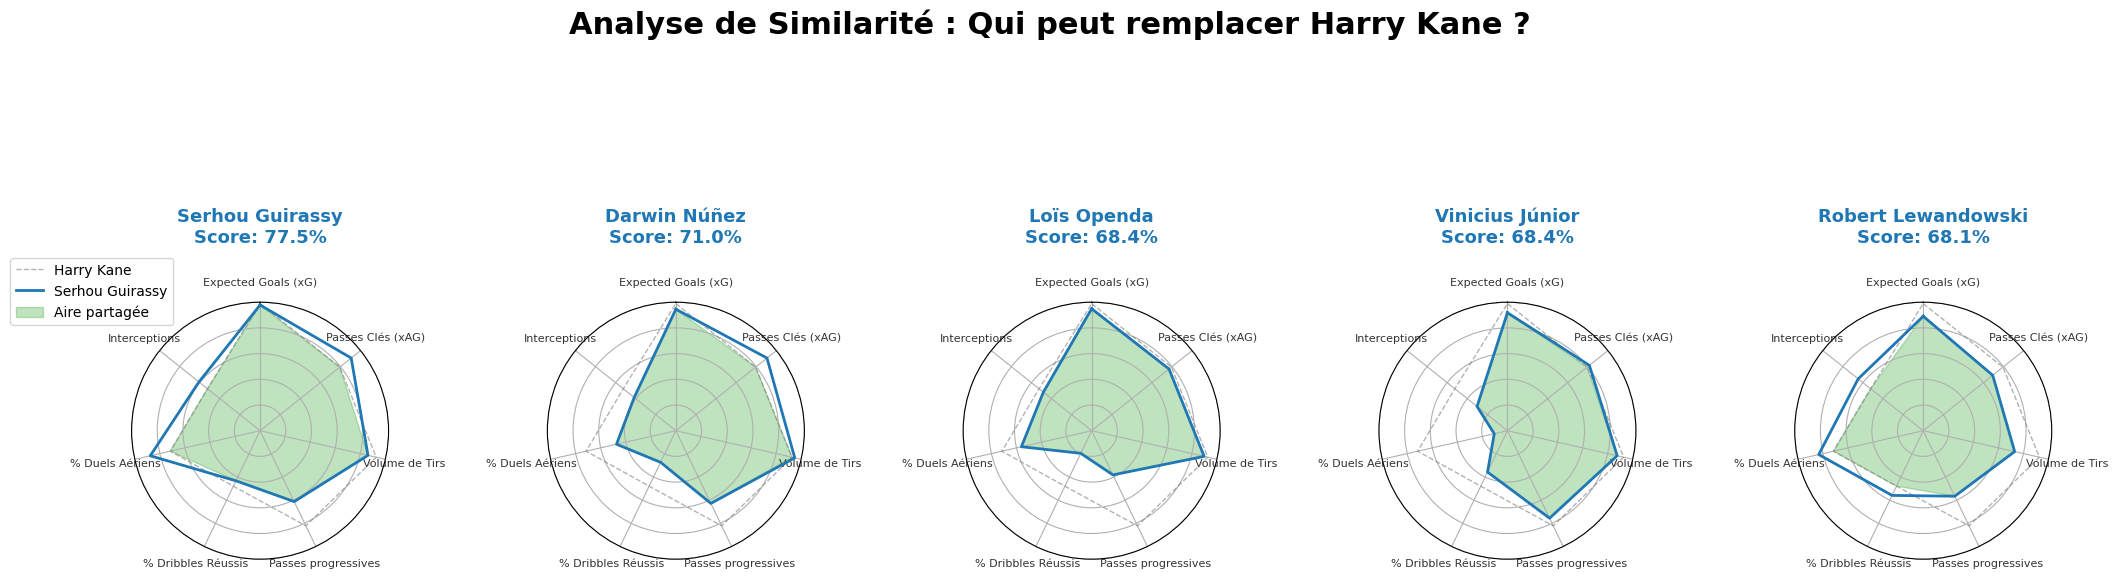

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# FONCTION : DATAVIZ DES CLONES (SMALL MULTIPLES) - VERSION OPTIMISÉE

def visualiser_top_clones(joueur_cible, df_resultats, df_data, colonnes_stats, labels):
    """
    Affiche les radars comparatifs avec une mise en page aérée et une échelle corrigée.
    """
    # 1. Extraction des stats du joueur cible
    v_cible = df_data[df_data['player'] == joueur_cible][colonnes_stats].iloc[0].values.tolist()
    v_cible += v_cible[:1] # Fermer le radar
    
    # 2. Préparation de la figure (Plus large et plus haute pour laisser respirer le texte)
    n_joueurs = len(df_resultats)
    fig, axes = plt.subplots(1, n_joueurs, figsize=(22, 7), subplot_kw=dict(polar=True))
    
    # Sécurité si 1 seul résultat
    if n_joueurs == 1: axes = [axes]
        
    # Calcul des angles
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # 3. Boucle sur les joueurs similaires
    for i, (idx, row) in enumerate(df_resultats.iterrows()):
        ax = axes[i]
        joueur_similaire = row['Joueur']
        score = row['Similarité (%)']
        
        # Stats du clone
        v_autre = df_data[df_data['player'] == joueur_similaire][colonnes_stats].iloc[0].values.tolist()
        v_autre += v_autre[:1]
        
        # Aire partagée
        v_intersection = np.minimum(v_cible, v_autre).tolist()
        
        # --- DESSIN ---
        # Joueur cible (Gris)
        ax.plot(angles, v_cible, color='gray', linewidth=1, linestyle='--', alpha=0.6, label=joueur_cible)
        
        # Clone (Bleu)
        ax.plot(angles, v_autre, color='#1f77b4', linewidth=2, label=joueur_similaire)
        
        # Intersection (Vert)
        ax.fill(angles, v_intersection, color='#2ca02c', alpha=0.3, label='Aire partagée')
        
        # --- DESIGN ET LISIBILITÉ ---
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        
        # Correction de l'échelle (Percentiles 0-100)
        ax.set_ylim(0, 100)
        ax.set_yticklabels([]) # Cache les chiffres internes pour la clarté
        
        # Optimisation des labels (Police plus petite et décalage)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8, color='#333333')
        
        # Ajustement manuel du titre individuel
        ax.set_title(f"{joueur_similaire}\nScore: {score}%", size=13, y=1.2, fontweight='bold', color='#1f77b4')

    # Ajustement global
    axes[0].legend(loc='upper left', bbox_to_anchor=(-0.5, 1.2), fontsize=10)
    plt.suptitle(f"Analyse de Similarité : Qui peut remplacer {joueur_cible} ?", 
                 size=22, y=1.05, fontweight='bold', color='black')
    
    # Force l'espacement entre les subplots pour éviter les chevauchements de texte
    plt.tight_layout(pad=3.0) 
    plt.show()

# --- EXÉCUTION ---

# 1. Calcul des clones (avec ta nouvelle fonction Cosine)
df_top5 = trouver_remplacant("Harry Kane", df_season, colonnes_percentiles, top=5)

# 2. Affichage (Conseil : utilise des labels courts si possible)
visualiser_top_clones("Harry Kane", df_top5, df_season, colonnes_percentiles, pretty_labels)